# Expected cross section uncertainties from SHiP and SND@HL-LHC measurements in RUN 4

## First, open the SHiP and SND@LHC simulations separately to scale the energies to the expected number of CCDIS events and sum them together

In [1]:
import ROOT as r

In [2]:
%jsroot off

In [3]:
BRTau2Mu = 0.174 #Branching Ratio tau lepton into muon decay 
includeBRTau2Mu = False #include the Branching ratio to muons in the tau contribution

## SHiP simulation file

Retrieve the dataframe

Plot the neutrino energy for CCDIS interactions, 

scale it to the expected number of CCDIS events for one year (**SPSC-P-369**)

In [4]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
gstfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
rootrackerfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

gstship = gstfileship.Get("gst")
rootrackership = rootrackerfileship.Get("gRooTracker")

gstship.AddFriend(rootrackership)
dfship = r.RDataFrame(gstship)

In [5]:
import numpy as np
from array import array
# logaritmic binning parameters
# We want 10 bins per decade, and we want the bins to appear equally spaced on a logarithmic scale
nbinsE = 10
E_min = 1.     
E_max = 10000.

# Generate borders of logarithms bins
Ebin_borders = np.logspace(np.log10(E_min), np.log10(E_max), nbinsE + 1)

In [6]:
E_max = 4000.
Ebin_borders = Ebin_borders[Ebin_borders<E_max]
nbinsE = len(Ebin_borders)-1

In [7]:
# Conversion to c++
Ebin_borders_c = array('d', Ebin_borders)

In [8]:
#filter per neutrino type
dfship_nutau = dfship.Filter("neu==16");
#target must be tungsten
dfship_nutau_W = dfship_nutau.Filter("tgt==1000741840");
hEship_CCDIS_nutau = dfship_nutau_W.Filter("cc&&dis").Histo1D(("hEship_CCDIS_nutau","Energy CCDIS nu tau",nbinsE,Ebin_borders_c),"Ev")

In [9]:
#filter per neutrino type
dfship_nutau_bar = dfship.Filter("neu==-16");
#target must be tungsten
dfship_nutau_bar_W = dfship_nutau_bar.Filter("tgt==1000741840");
hEship_CCDIS_nutau_bar = dfship_nutau_bar_W.Filter("cc&&dis").Histo1D(("hEship_CCDIS_nutau_bar","Energy CCDIS nu tau bar",nbinsE,Ebin_borders_c),"Ev")

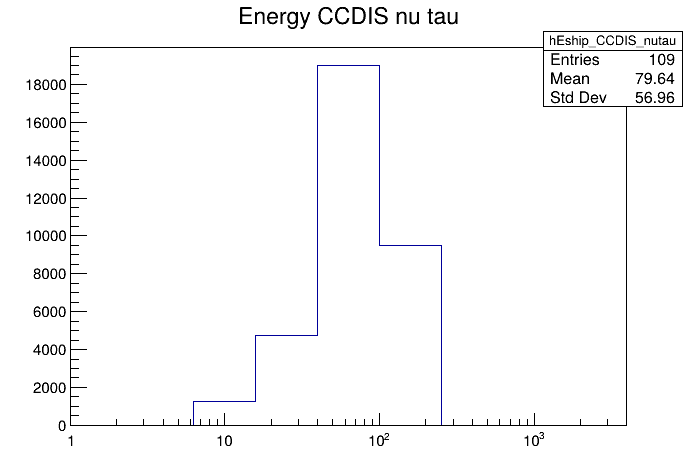

In [10]:
n_nutau_CCDIS_ship = 2.3e+3 * 15 #15 years of data taking in the Si/W target
#n_nutau_CCDIS_ship = 2.5e+3 #15 years of data taking in the Si/W target

if includeBRTau2Mu:
    n_nutau_CCDIS_ship = n_nutau_CCDIS_ship * BRTau2Mu

cE_CCDIS_nutau = r.TCanvas()
hEship_CCDIS_nutau.Scale(n_nutau_CCDIS_ship/hEship_CCDIS_nutau.Integral())
hEship_CCDIS_nutau.Draw("histo")
cE_CCDIS_nutau.SetLogx()
cE_CCDIS_nutau.Draw()

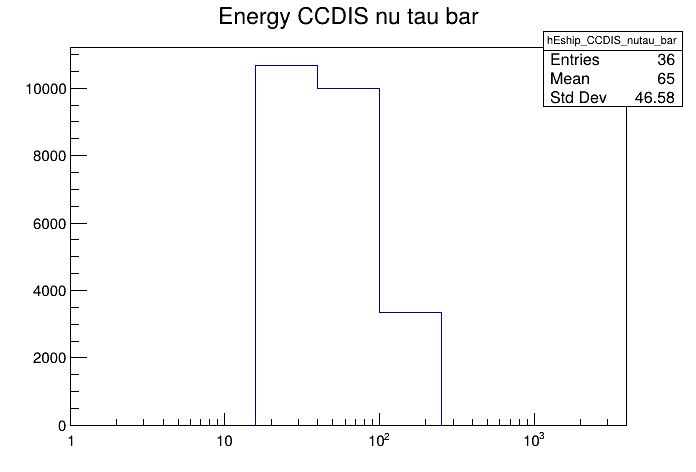

In [11]:
n_nutau_bar_CCDIS_ship = 1.6e+3 * 15 #15 years of data taking in the Si/W target
#n_nutau_bar_CCDIS_ship = 1.1e+3 #15 years of data taking in the Si/W target

if includeBRTau2Mu:
    n_nutau_bar_CCDIS_ship = n_nutau_bar_CCDIS_ship * BRTau2Mu

cE_CCDIS_nutau_bar = r.TCanvas()
hEship_CCDIS_nutau_bar.Scale(n_nutau_bar_CCDIS_ship/hEship_CCDIS_nutau_bar.Integral())
hEship_CCDIS_nutau_bar.Draw("histo")
cE_CCDIS_nutau_bar.SetLogx()
cE_CCDIS_nutau_bar.Draw()

## SND@HL-LHC

Same as before, we open the other file and we plot the other histogram of energies

The number of expected neutrino interactions is from **LHCC-P-026**

In [12]:
prepath = "/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/"
gstfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
rootrackerfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

gstsndlhc = gstfilesndlhc.Get("gst")
rootrackersndlhc = rootrackerfilesndlhc.Get("gRooTracker")

gstsndlhc.AddFriend(rootrackersndlhc)
dfsndlhc = r.RDataFrame(gstsndlhc)

In [13]:
#filter per neutrino type
dfsndlhc_nutau = dfsndlhc.Filter("neu==16");
#target must be tungsten
dfsndlhc_nutau_W = dfsndlhc_nutau.Filter("tgt==1000741840");
hEsndlhc_CCDIS_nutau = dfsndlhc_nutau_W.Filter("cc&&dis").Histo1D(("hEsndlhc_CCDIS_nutau","Energy CCDIS nu tau",nbinsE,Ebin_borders_c),"Ev")

In [14]:
#filter per neutrino type
dfsndlhc_nutau_bar = dfsndlhc.Filter("neu==-16");
#target must be tungsten
dfsndlhc_nutau_bar_W = dfsndlhc_nutau_bar.Filter("tgt==1000741840");
hEsndlhc_CCDIS_nutau_bar = dfsndlhc_nutau_bar_W.Filter("cc&&dis").Histo1D(("hEsndlhc_CCDIS_nutau_bar","Energy CCDIS nu tau bar",nbinsE,Ebin_borders_c),"Ev")

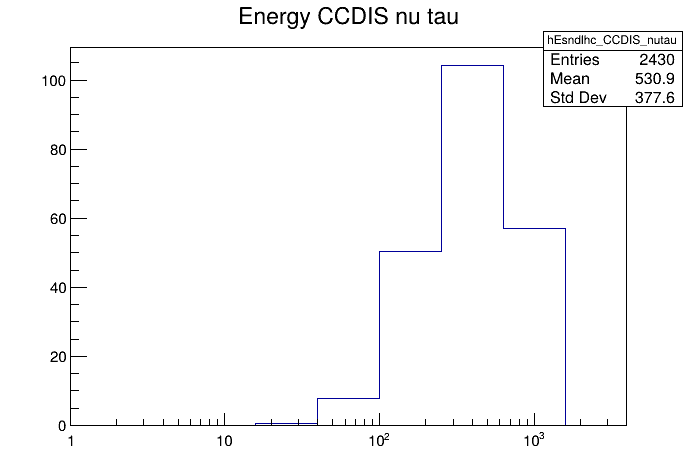

In [15]:
n_nutau_CCDIS_sndlhc = 2.2e+2

if includeBRTau2Mu:
    n_nutau_CCDIS_sndlhc = n_nutau_CCDIS_sndlhc * BRTau2Mu

cEsndlhc_CCDIS_nutau = r.TCanvas()
hEsndlhc_CCDIS_nutau.Scale(n_nutau_CCDIS_sndlhc/hEsndlhc_CCDIS_nutau.Integral())
hEsndlhc_CCDIS_nutau.Draw("histo")
cEsndlhc_CCDIS_nutau.SetLogx()
cEsndlhc_CCDIS_nutau.Draw()

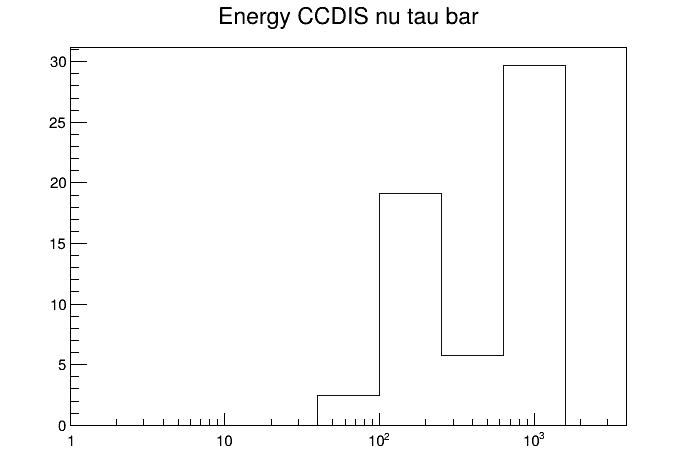

In [16]:
n_nutau_bar_CCDIS_sndlhc = 5.7e+1

if includeBRTau2Mu:
    n_nutau_bar_CCDIS_sndlhc = n_nutau_bar_CCDIS_sndlhc * BRTau2Mu

cEsndlhc_CCDIS_nutau_bar = r.TCanvas()
hEsndlhc_CCDIS_nutau_bar.Scale(n_nutau_bar_CCDIS_sndlhc/hEsndlhc_CCDIS_nutau_bar.Integral())
hEsndlhc_CCDIS_nutau_bar.Draw("histo")
cEsndlhc_CCDIS_nutau_bar.SetLogx()
cEsndlhc_CCDIS_nutau_bar.Draw()

## SHiP + SNDLHC neutrino energies

Summing together the two histograms

Resetting the bin errors to the sqrt of bin content for energy bin

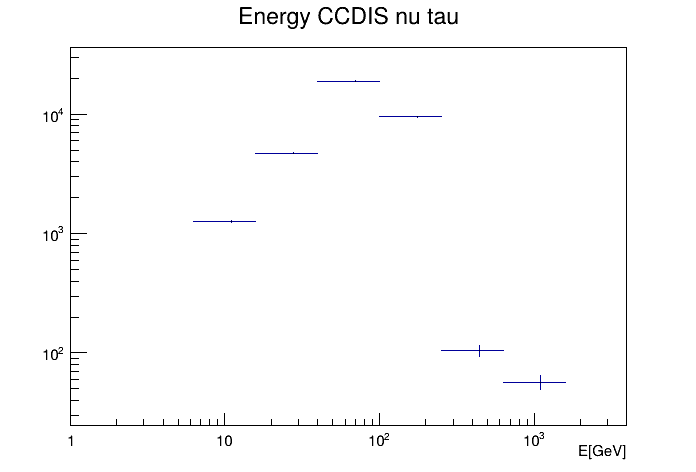

In [17]:
r.gStyle.SetOptStat(0)
cE_CCDIS_nutau = r.TCanvas()
hE_CCDIS_nutau = r.TH1D("hE_CCDIS_nutau","Energy CCDIS nu tau",nbinsE,Ebin_borders_c)

hE_CCDIS_nutau.Add(hEship_CCDIS_nutau.GetPtr())
hE_CCDIS_nutau.Add(hEsndlhc_CCDIS_nutau.GetPtr())


for i in range(1, hE_CCDIS_nutau.GetNbinsX() + 1):
    content = hE_CCDIS_nutau.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_nutau.SetBinError(i, r.TMath.Sqrt(content))

hE_CCDIS_nutau.GetXaxis().SetTitle("E[GeV]")
hE_CCDIS_nutau.Draw("E")
cE_CCDIS_nutau.SetLogy()
cE_CCDIS_nutau.SetLogx()
cE_CCDIS_nutau.Draw()

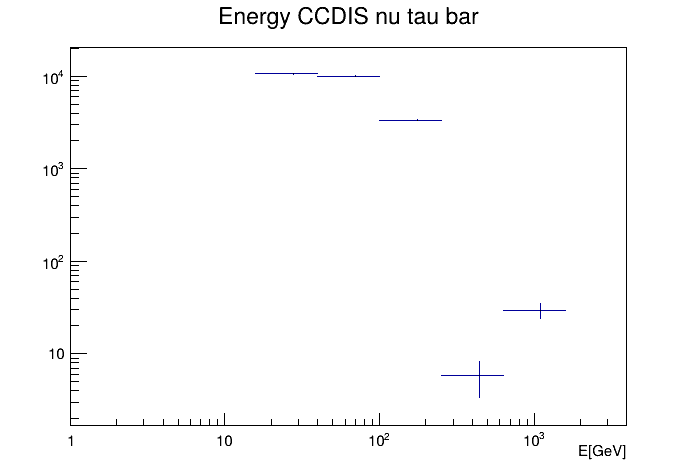

In [18]:
cE_CCDIS_nutau_bar = r.TCanvas()
hE_CCDIS_nutau_bar = r.TH1D("hE_CCDIS_nutau_bar","Energy CCDIS nu tau bar",nbinsE,Ebin_borders_c)

hE_CCDIS_nutau_bar.Add(hEship_CCDIS_nutau_bar.GetPtr())
hE_CCDIS_nutau_bar.Add(hEsndlhc_CCDIS_nutau_bar.GetPtr())


for i in range(1, hE_CCDIS_nutau_bar.GetNbinsX() + 1):
    content = hE_CCDIS_nutau_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_nutau_bar.SetBinError(i, r.TMath.Sqrt(content))

hE_CCDIS_nutau_bar.GetXaxis().SetTitle("E[GeV]")
hE_CCDIS_nutau_bar.Draw("E")
cE_CCDIS_nutau_bar.SetLogy()
cE_CCDIS_nutau_bar.SetLogx()
cE_CCDIS_nutau_bar.Draw()

# Retrieving the cross section

Now we can move to the cross sections CCDIS

Both for nutau and anti-nutau, merging the SHiP and SNDLHC

We rescale them to the relative error from the neutrino energy spectra

In [19]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
chaingst = r.TChain("gst")
chaingst.Add(prepath+"nu_1year_fluxhanae34.gst.root")
chaingst.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")

chainrootracker = r.TChain("gRooTracker")
chainrootracker.Add(prepath+"nu_1year_fluxhanae34.rootracker.root")
chainrootracker.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")
#gstfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
#rootrackerfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

#gstfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
#rootrackerfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

#gsttree = gstfile.Get("gst")
#rootrackertree = rootrackerfile.Get("gRooTracker")

#gsttree.AddFriend(rootrackertree)
chaingst.AddFriend(chainrootracker)

In [20]:
df = r.RDataFrame(chaingst);

In [21]:
df1 = df.Define("log10_E","log10(Ev)")
df2 = df1.Define("xsecN_overE","gRooTracker.EvtXSec/(Ev*184)")

In [22]:
#filter per neutrino type
df_nutau = df2.Filter("neu==16");
#target must be tungsten
df_nutau_W = df_nutau.Filter("tgt==1000741840");

In [23]:
nbinsxsec = 1000;
minxsec = 0.;
maxxsec = 1.;

In [24]:
def selectchannel(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_nutau_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [25]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [26]:
profiles = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel(cc, inttype, hitnuc,charm);
                profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [27]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [28]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles.append(selectdf.Profile1D(("prof_"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

In [29]:
h_sum = r.TH1D("h_sum","total cross section",nbinsE,Ebin_borders_c)
for profile in profiles:
    h_sum.Add(profile.ProjectionX("h_"+profile.GetName()))

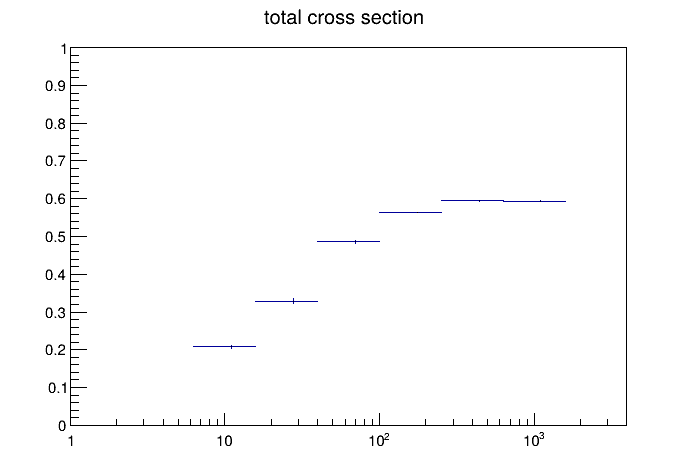

In [30]:
c0 = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,1.0,"Y")
c0.SetLogx()
c0.Draw()

In [31]:
h_sum_ccdis = r.TH1D("h_sum_ccdis","ccdis cross section nutau",nbinsE,Ebin_borders_c)
for profile in profiles:
    if "dis" in profile.GetName():
        h_sum_ccdis.Add(profile.ProjectionX("h_ccdis_"+profile.GetName()))

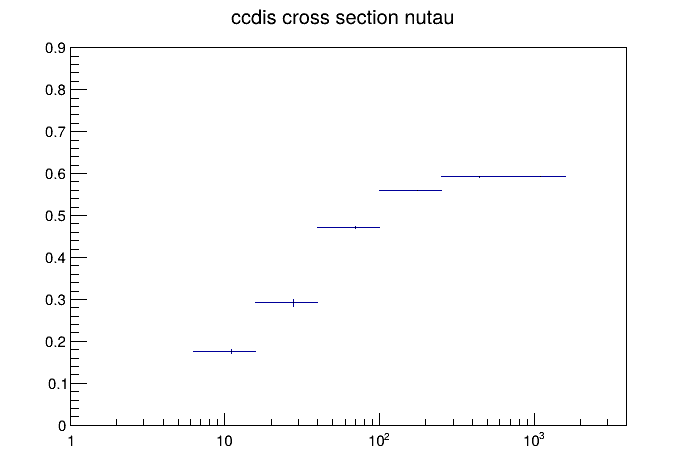

In [32]:
c1 = r.TCanvas()
h_sum_ccdis.Draw()
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
c1.SetLogx()
c1.Draw()

# Now for anti neutrinos

In [33]:
#filter per neutrino type
df_nutau_bar = df2.Filter("neu==-16");
#target must be tungsten
df_nutau_bar_W = df_nutau_bar.Filter("tgt==1000741840");

In [34]:
def selectchannel_bar(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_nutau_bar_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [35]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [36]:
profiles_bar = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel_bar(cc, inttype, hitnuc,charm);
                profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [37]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel_bar("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [38]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel_bar(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

In [39]:
h_sum_bar = r.TH1D("h_sum_bar","total cross section anti neutrino",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    h_sum_bar.Add(profile.ProjectionX("h_bar"+profile.GetName()))

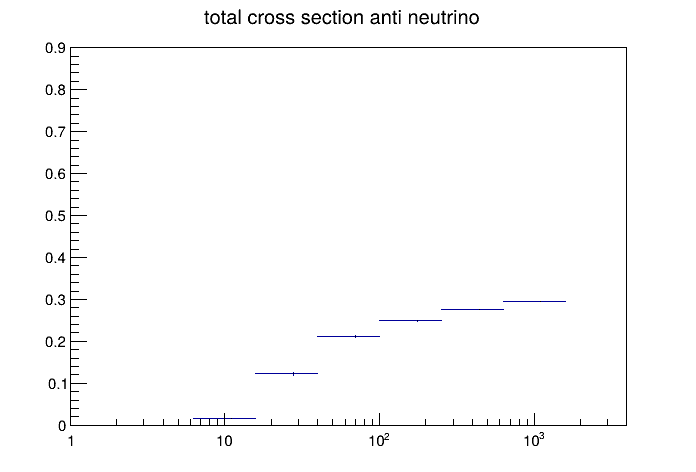

In [40]:
c10 = r.TCanvas()
h_sum_bar.Draw()
h_sum_bar.SetAxisRange(0,0.9,"Y")
c10.SetLogx()
c10.Draw()

In [41]:
h_sum_bar_ccdis = r.TH1D("h_sum_bar_ccdis","ccdis cross section anti nutau",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    if "dis" in profile.GetName():
        h_sum_bar_ccdis.Add(profile.ProjectionX("h_ccdis_bar"+profile.GetName()))

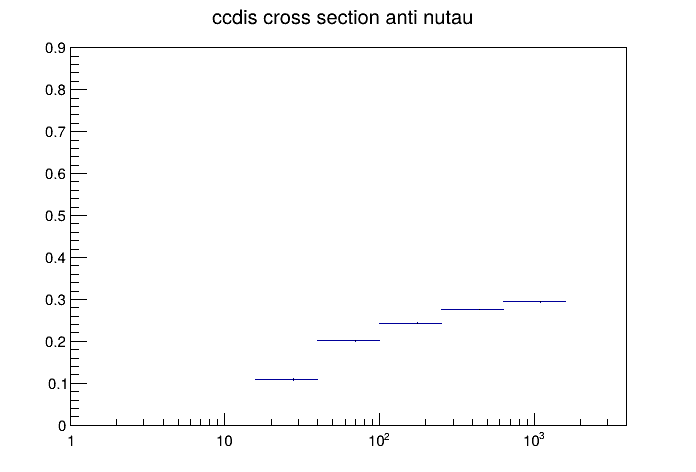

In [42]:
c11 = r.TCanvas()
h_sum_bar_ccdis.Draw()
h_sum_bar_ccdis.SetAxisRange(0,0.9,"Y")
c11.SetLogx()
c11.Draw()

## Including both nu and nu bar

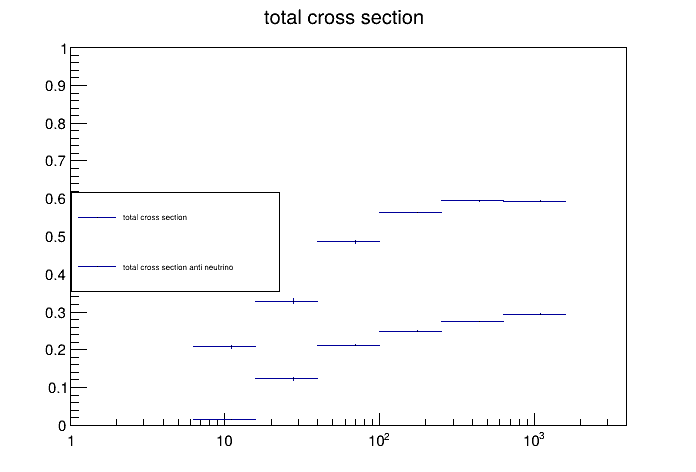

In [43]:
c_comparison = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,1.0,"Y")
h_sum_bar.Draw("SAME")
c_comparison.BuildLegend()
c_comparison.SetLogx()
c_comparison.Draw()


In [44]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_nutau.GetNbinsX() + 1):
    if (hE_CCDIS_nutau.GetBinContent(i)==0):
        h_sum_ccdis.SetBinContent(i,0) #not plotting where we do not have statistics
        continue
    relerror = hE_CCDIS_nutau.GetBinError(i)/hE_CCDIS_nutau.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_ccdis.SetBinError(i, relerror * h_sum_ccdis.GetBinContent(i))

In [45]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_nutau_bar.GetNbinsX() + 1):
    if (hE_CCDIS_nutau_bar.GetBinContent(i)==0):
        h_sum_bar_ccdis.SetBinContent(i,0) #not plotting where we do not have statistics
        continue
    relerror = hE_CCDIS_nutau_bar.GetBinError(i)/hE_CCDIS_nutau_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_bar_ccdis.SetBinError(i, relerror * h_sum_bar_ccdis.GetBinContent(i))

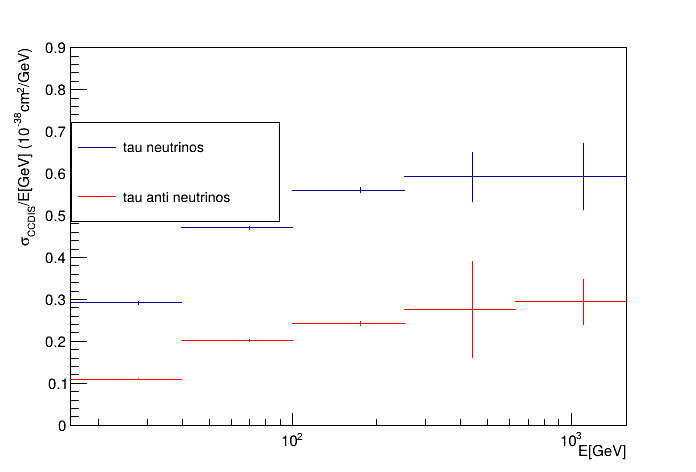

In [46]:
c_comparison_ccdis = r.TCanvas()
h_sum_ccdis.Draw("E")
h_sum_ccdis.SetTitle("tau neutrinos")
h_sum_ccdis.SetStats(False)
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
#h_sum_ccdis.SetAxisRange(10,4000.,"X")
h_sum_bar_ccdis.SetStats(False)
h_sum_bar_ccdis.Draw("SAME && E")
h_sum_bar_ccdis.SetLineColor(r.kRed)
h_sum_bar_ccdis.SetTitle("tau anti neutrinos")
h_sum_ccdis.GetXaxis().SetTitle("E[GeV]")
h_sum_ccdis.GetYaxis().SetTitle("#sigma_{CCDIS}/E[GeV] (10^{-38}cm^{2}/GeV)")
h_sum_ccdis.GetXaxis().SetRangeUser(20,1000)
c_comparison_ccdis.BuildLegend()
c_comparison_ccdis.SetLogx()
h_sum_ccdis.SetTitle("")
c_comparison_ccdis.Draw()

In [47]:
!ls /eos/user/a/aiuliano/Synched/Archivio_cronologico/Maggio_2026

 2026_05_07_SHiP_SND_Status_Computing_WorkShop.odp
 2026_05_07_SHiP_SND_Status_Computing_WorkShop.pdf
 2026_05_07_cpuload_comparison.png
 2026_05_07_memory_usage_comparison.png
 2026_05_14_cpuload_comparison.png
 2026_05_14_memory_usage_comparison.png
 2026_05_18_ScanningLabNaples_Status.odp
 2026_05_18_ScanningLabNaples_Status.pdf
 2026_05_21_cpuload_comparison.png
 2026_05_21_memory_usage_comparison.png
 2026_05_25_ScanningLabNaples_Status.odp
 2026_05_25_ScanningLabNaples_Status.pdf
 2026_05_28_cpuload_comparison.png
 2026_05_28_memory_usage_comparison.png
 2026_05_29_general_updates.odp
 2026_05_29_general_updates.pdf
 2logtestautotools_geminiubuntu26.log
 2testautotools_geminiubuntu26.sh
 Benchmark_Hanae_May_2026.png
 CCDIS_SHiP_SNDLHC
 CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_0.png
 CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_0.root
 CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.pdf
 CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.png
 CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.root
 CCDI

In [48]:
c_comparison_ccdis.Print("/eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.root")
c_comparison_ccdis.Print("/eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.png")

Info in <TCanvas::SaveAs>: ROOT file /eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.root has been created
Info in <TCanvas::Print>: png file /eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.png has been created


In [49]:
c_comparison_ccdis.Print("/eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.jpg")

Info in <TCanvas::Print>: jpg file /eos/user/a/aiuliano/Synched/Archivio_cronologico/Giugno_2026/CCDIS_SHiP2025_SNDLHC/CCDIS_XSEC_GenieRooTracker_SHiP+SNDLHC_nutau.jpg has been created
